In [1]:
import pandas as pd
import numpy as np

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [6]:
import pandas as pd

true = pd.read_csv("/content/True.csv", encoding='latin-1', on_bad_lines='skip')

In [8]:
true.sample(5)

,title,text,subject,date
5727,U.S. coal miners applaud Republican axing of s...,WASHINGTON (Reuters) - The battered U.S. coal ...,politicsNews,"February 2, 2017"
9210,Clinton thrilled Obama 'has my back' in U.S. e...,WASHINGTON (Reuters) - Presumptive Democratic ...,politicsNews,"June 9, 2016"
11217,"U.S. halts new coal leases on federal land, fi...",WASHINGTON (Reuters) - The Obama administratio...,politicsNews,"January 15, 2016"
20371,"Hurricane Irma kills 10 in Cuba, Castro calls ...",HAVANA (Reuters) - President Raul Castro calle...,worldnews,"September 11, 2017"
14292,Rosneft's Sechin to miss hearing at ex-ministe...,MOSCOW (Reuters) - The head of Russian state o...,worldnews,"November 21, 2017"


In [9]:
fake = pd.read_csv("/content/Fake.csv", encoding='latin-1', on_bad_lines='skip')

/tmp/ipykernel_1496/3733590210.py:1: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171) have mixed types. Specify dtype option on import or set low_memory=False.
  fake = pd.read_csv("/content/Fake.csv", encoding='latin-1', on_bad_lines='skip')


In [6]:
fake

,title,text,subject,date,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 162,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,News,31-Dec-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,31-Dec-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,30-Dec-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Trump Is So Obsessed He Even Has Obamaâs Na...,"On Christmas day, Donald Trump announced that ...",News,29-Dec-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,25-Dec-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23496,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,16-Jan-16,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23497,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,16-Jan-16,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23498,Sunnistan: US and Allied âSafe Zoneâ Plan ...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,15-Jan-16,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23499,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,14-Jan-16,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
fake["label"]=1
true["label"]=0

In [11]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23501 entries, 0 to 23500
Columns: 173 entries, title to label
dtypes: int64(1), object(172)
memory usage: 31.0+ MB


In [13]:
fake.columns


Index(['title', 'text', 'subject', 'date', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 163', 'Unnamed: 164', 'Unnamed: 165', 'Unnamed: 166',
       'Unnamed: 167', 'Unnamed: 168', 'Unnamed: 169', 'Unnamed: 170',
       'Unnamed: 171', 'label'],
      dtype='object', length=173)

In [14]:
df=pd.concat([true,fake],axis=0,ignore_index=True)

In [15]:
df

,title,text,subject,date,label,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,...,Unnamed: 162,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44913,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,16-Jan-16,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44914,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,16-Jan-16,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44915,Sunnistan: US and Allied âSafe Zoneâ Plan ...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,15-Jan-16,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44916,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,14-Jan-16,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       ...
       'Unnamed: 162', 'Unnamed: 163', 'Unnamed: 164', 'Unnamed: 165',
       'Unnamed: 166', 'Unnamed: 167', 'Unnamed: 168', 'Unnamed: 169',
       'Unnamed: 170', 'Unnamed: 171'],
      dtype='object', length=173)

In [17]:
new_df=df[['title', 'text', 'subject', 'date', 'label']]

In [18]:
new_df

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0
...,...,...,...,...,...
44913,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,16-Jan-16,1
44914,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,16-Jan-16,1
44915,Sunnistan: US and Allied âSafe Zoneâ Plan ...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,15-Jan-16,1
44916,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,14-Jan-16,1


In [19]:
new_df=new_df.sample(frac=1).reset_index(drop=True)

In [20]:
new_df.sample(19)

,title,text,subject,date,label
27383,"Congress rejects Obama veto, Saudi September 1...",WASHINGTON (Reuters) - Congress on Wednesday o...,politicsNews,"September 28, 2016",0
32085,"Clintons earned $10.75 million in 2015, paid 3...",WASHINGTON (Reuters) - Hillary Clinton on Frid...,politicsNews,"August 12, 2016",0
34049,Former Secretary of State Powell will vote for...,"(Reuters) - Colin Powell, who served as secret...",politicsNews,"October 25, 2016",0
11700,WHOA! Woman Born In NAZI GERMANY Says Trump Do...,A woman who was born in Nazi Germany says that...,left-news,10-Feb-17,1
10379,Bernie Sanders Asks One Question: The Respons...,"During a campaign event in Iowa Falls, Iowa on...",News,25-Jan-16,1
35178,MOST UNWANTED MAN IN THE WORLD: Argentinians D...,January 2017 can t come fast enough for Americ...,Government News,23-Mar-16,1
26079,Short Film Envisions Effect Global Warming Wi...,The world was stunned when Donald Trump pulled...,News,13-Jun-17,1
32527,Chinese sub docks at Malaysian port for second...,KUALA LUMPUR (Reuters) - A Chinese submarine h...,worldnews,"September 13, 2017",0
29685,"IF AMERICA ELECTS HILLARY, She Promises To Rew...",Hillary s over-the-top plan to tax the consume...,politics,21-Apr-16,1
30577,Brady Campaign's ad draws ire of U.S. anti-gun...,BOSTON (Reuters) - The Brady Campaign to Preve...,politicsNews,"April 29, 2016",0


In [21]:
df=new_df.sample(frac=1).reset_index(drop=True)

In [22]:
df

,title,text,subject,date,label
0,GOP Consultant Tells Black Reporter She Wants...,"Yes, this actually happened.During a panel dis...",News,7-Mar-16,1
1,U.S. EPA bans some scientists from independent...,WASHINGTON (Reuters) - The U.S. Environmental ...,politicsNews,"October 31, 2017",0
2,Czech election winner Babis warms to minority ...,PRAGUE (Reuters) - The anti-establishment ANO ...,worldnews,"October 27, 2017",0
3,Puerto Rico debt bill cleared for Thursday U.S...,WASHINGTON (Reuters) - Legislation helping Pue...,politicsNews,"June 9, 2016",0
4,"Trump meets Japan, Australia leaders over trad...",MANILA (Reuters) - U.S. President Donald Trump...,worldnews,"November 13, 2017",0
...,...,...,...,...,...
44913,Trump administration releases rules on disclos...,WASHINGTON (Reuters) - The Trump administratio...,politicsNews,"November 15, 2017",0
44914,EU LEADERS PLEDGE EXTRA â¬1 Billion In Aid To...,It won t lead to any solution. It s a kind of...,left-news,23-Sep-15,1
44915,Kellyanne Conway Says All Intel On Russia Mus...,"Kellyanne Conway, Donald Trump s adviser, says...",News,15-Jan-17,1
44916,HILARIOUS TRUMP CHRISTMAS VIDEO: âItâs The...,,left-news,1-Dec-16,1


In [23]:
df["content"]=df["title"] + " " + ["text"]

In [24]:
df["content"]

,content
0,GOP Consultant Tells Black Reporter She Wants...
1,U.S. EPA bans some scientists from independent...
2,Czech election winner Babis warms to minority ...
3,Puerto Rico debt bill cleared for Thursday U.S...
4,"Trump meets Japan, Australia leaders over trad..."
...,...
44913,Trump administration releases rules on disclos...
44914,EU LEADERS PLEDGE EXTRA â¬1 Billion In Aid To...
44915,Kellyanne Conway Says All Intel On Russia Mus...
44916,HILARIOUS TRUMP CHRISTMAS VIDEO: âItâs The...


In [25]:
df["content"]=df["content"].str.lower()

In [22]:
df["content"]

,content
0,this female u.s. senator just said what weâ...
1,maddow compares trump to 1968 racist candidat...
2,muslim assimilation update: migrants arrested ...
3,cambodia marks independence from france with d...
4,trump does fallonâs tonight show: talks abou...
...,...
44913,popular actor travels to calais jungle to garn...
44914,tunisia working with uae on terrorist threat f...
44915,newt gingrich admits trump is no longer drain...
44916,soldier: âhereâs why trumpâs transgender...


In [26]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [27]:
df["content"]=df["content"].apply(remove_punctuation)

In [25]:
df["content"]

,content
0,this female us senator just said what weâre...
1,maddow compares trump to 1968 racist candidat...
2,muslim assimilation update migrants arrested f...
3,cambodia marks independence from france with d...
4,trump does fallonâs tonight show talks about...
...,...
44913,popular actor travels to calais jungle to garn...
44914,tunisia working with uae on terrorist threat f...
44915,newt gingrich admits trump is no longer drain...
44916,soldier âhereâs why trumpâs transgender ...


In [28]:
def remove_extra_spaces(text):
    return " ".join(text.split())

In [29]:
df["content"]=df["content"].apply(remove_punctuation)

In [30]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [31]:

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)

In [32]:
df['content'] = df['content'].apply(remove_stopwords)

In [31]:
df["content"]

,content
0,female us senator said weâre thinking trump ...
1,maddow compares trump 1968 racist candidate ge...
2,muslim assimilation update migrants arrested s...
3,cambodia marks independence france doves ballo...
4,trump fallonâs tonight show talks hillary de...
...,...
44913,popular actor travels calais jungle garner sym...
44914,tunisia working uae terrorist threat female ji...
44915,newt gingrich admits trump longer draining swa...
44916,soldier âhereâs trumpâs transgender mili...


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [34]:
X=df[["content"]]
y=df["label"]

In [43]:
v=TfidfVectorizer()
X=v.fit_transform(X["content"])

IndexError: Index dimension must be 1 or 2

In [35]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 472052 stored elements and shape (44918, 26969)>

In [36]:
print(v.get_feature_names_out())

# TF-IDF matrix
print(X.toarray())

['00' '0149' '02' ... 'zâ' 'ªâ' 'å½iå¾ek']
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
X_test.shape

(8984, 26969)

In [39]:
X_train.shape

(35934, 26969)

In [40]:
y_test.shape

(8984,)

In [41]:
y_train.shape

(35934,)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [39]:
model1=LogisticRegression()
model1.fit(X_train,y_train)
y_p=model1.predict(X_test)

In [40]:
print(accuracy_score(y_test,y_p))
print(classification_report(y_test,y_p))

0.9591495992876224
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4311
           1       0.97      0.95      0.96      4673

    accuracy                           0.96      8984
   macro avg       0.96      0.96      0.96      8984
weighted avg       0.96      0.96      0.96      8984



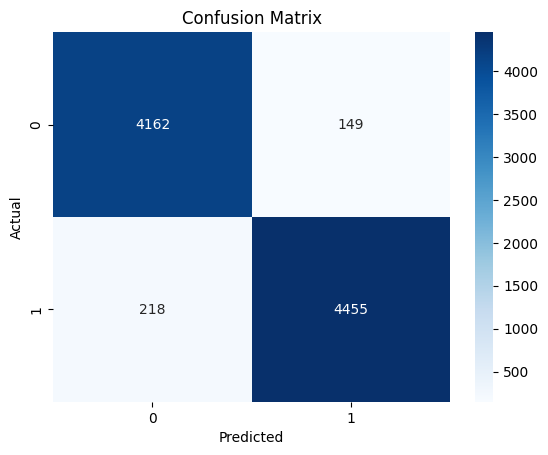

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_p)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
svm_model = SVC(max_iter=5000,C=0.5)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [45]:
print("SVM Accuracy:")
print(accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy:
0.966273374888691
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      4311
           1       0.98      0.96      0.97      4673

    accuracy                           0.97      8984
   macro avg       0.97      0.97      0.97      8984
weighted avg       0.97      0.97      0.97      8984



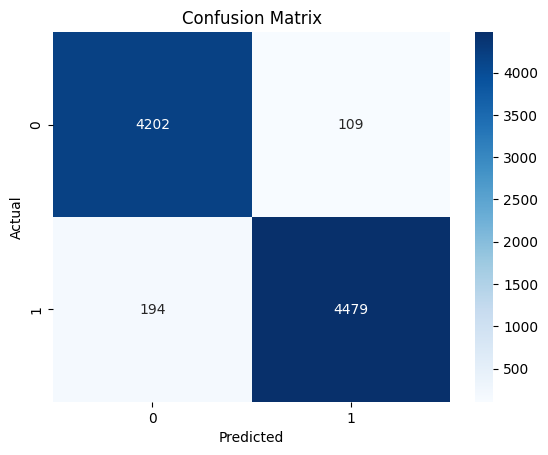

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()